In [71]:
import numpy as np
import glob
from skimage import io, exposure, img_as_ubyte, filters, measure, morphology
from scipy.ndimage import binary_fill_holes
import os
import matplotlib.pyplot as plt

In [42]:
load_path = "C:\\Users\\is5046he\\Work Folders\\Documents\\PhD\\Finances\\grant applications\\250925_Fysiografen Equipment 2025\\images\\original\\*.png"
save_folder = "C:\\Users\\is5046he\\Work Folders\\Documents\\PhD\\Finances\\grant applications\\250925_Fysiografen Equipment 2025\\images\\enhanced"

os.makedirs(save_folder, exist_ok=True)

image_files = glob.glob(load_path)


print(image_files)


['C:\\Users\\is5046he\\Work Folders\\Documents\\PhD\\Finances\\grant applications\\250925_Fysiografen Equipment 2025\\images\\original\\aurelia_aurita.png', 'C:\\Users\\is5046he\\Work Folders\\Documents\\PhD\\Finances\\grant applications\\250925_Fysiografen Equipment 2025\\images\\original\\Cyanea_larckii.png', 'C:\\Users\\is5046he\\Work Folders\\Documents\\PhD\\Finances\\grant applications\\250925_Fysiografen Equipment 2025\\images\\original\\gioniunemus_sp.png', 'C:\\Users\\is5046he\\Work Folders\\Documents\\PhD\\Finances\\grant applications\\250925_Fysiografen Equipment 2025\\images\\original\\leucartiara_octona.png', 'C:\\Users\\is5046he\\Work Folders\\Documents\\PhD\\Finances\\grant applications\\250925_Fysiografen Equipment 2025\\images\\original\\luidia_sarsi.png', 'C:\\Users\\is5046he\\Work Folders\\Documents\\PhD\\Finances\\grant applications\\250925_Fysiografen Equipment 2025\\images\\original\\mnemeopsis_leidyi.png', 'C:\\Users\\is5046he\\Work Folders\\Documents\\PhD\\Financ

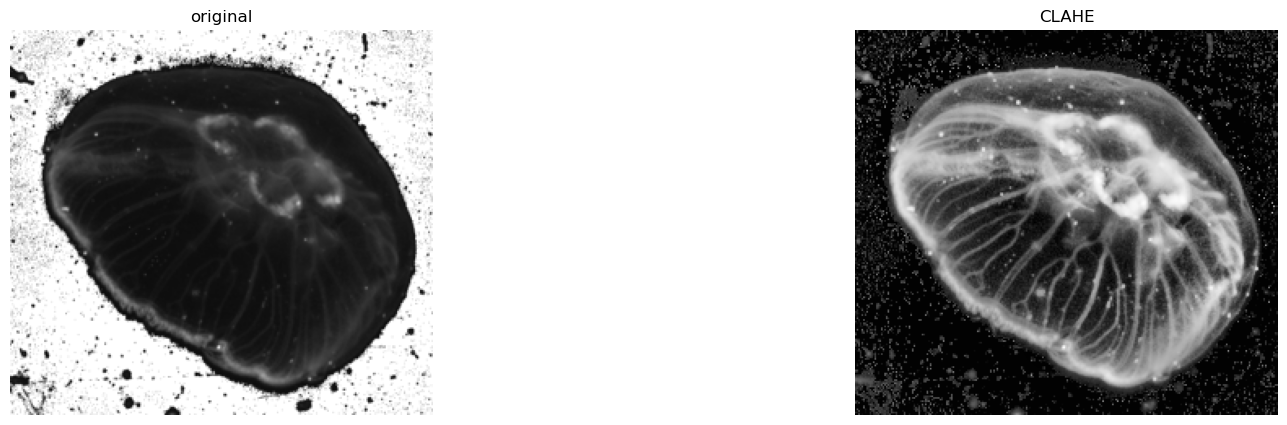

In [118]:
import os
import matplotlib.pyplot as plt
from skimage import io, exposure, img_as_ubyte, filters, measure, morphology
from scipy.ndimage import binary_fill_holes

ind = 0
selected_img = image_files[ind]
img = io.imread(selected_img)  # grayscale
filename = os.path.basename(selected_img)
save_path = os.path.join(save_folder, filename)

k = 62

# Apply CLAHE
img_enhanced = exposure.equalize_adapthist(img, clip_limit=0.04, kernel_size=(k, k))

# Plotting
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('original')

plt.subplot(1,2,2)
plt.imshow(img_enhanced, cmap='gray')
plt.axis('off')
plt.title('CLAHE')

plt.show()

# Save enhanced image
io.imsave(save_path, img_as_ubyte(img_enhanced))


In [128]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, exposure, img_as_ubyte, measure, morphology, filters
from scipy.ndimage import binary_fill_holes
from skimage.morphology import binary_closing, disk


# ---- Parameters ----
ind = 1
selected_img = image_files[ind]
img = io.imread(selected_img)  # grayscale
filename = os.path.basename(selected_img)
save_path = os.path.join(save_folder, filename)
k = 62  # CLAHE kernel size

# ---- Apply CLAHE ----
img_enhanced = exposure.equalize_adapthist(img, clip_limit=0.04, kernel_size=(k, k))

# ---- Threshold and create binary mask ----
thresh = filters.threshold_otsu(img_enhanced)
binary_mask = img_enhanced > thresh

# Fill holes
filled_mask = binary_fill_holes(binary_mask)
filled_mask = np.squeeze(filled_mask).astype(bool)  # ensure 2D boolean

# Morphological closing (footprint must be boolean)
footprint = disk(5).astype(bool)
closed_mask = binary_closing(filled_mask, footprint=footprint)

# Remove small objects
cleaned_mask = morphology.remove_small_objects(closed_mask, min_size=50)

# ---- Label connected components and find largest blob ----
labels = measure.label(cleaned_mask)
props = measure.regionprops(labels)

if len(props) > 0:
    largest_blob = max(props, key=lambda x: x.area)
    largest_mask = labels == largest_blob.label
else:
    largest_mask = cleaned_mask  # fallback

# ---- Apply mask to enhanced image ----
img_blob = np.zeros_like(img_enhanced)
img_blob[largest_mask] = img_enhanced[largest_mask]

# ---- Plotting ----
plt.figure(figsize=(20,5))
plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('original')

plt.subplot(1,4,2)
plt.imshow(img_enhanced, cmap='gray')
plt.axis('off')
plt.title('CLAHE')

plt.subplot(1,4,3)
plt.imshow(cleaned_mask, cmap='gray')
plt.axis('off')
plt.title('binary mask')

plt.subplot(1,4,4)
plt.imshow(img_blob, cmap='gray')
plt.axis('off')
plt.title('largest blob')

plt.show()

# ---- Save images ----
io.imsave(save_path, img_as_ubyte(img_enhanced))  # CLAHE enhanced
blob_save_path = os.path.join(save_folder, f"blob_{filename}")
io.imsave(blob_save_path, img_as_ubyte(img_blob))  # largest blob only


C:\Users\is5046he\AppData\Local\Temp\ipykernel_20820\2599832391.py:21: UserWarning: threshold_otsu is expected to work correctly only for grayscale images; image shape (403, 264, 3) looks like that of an RGB image.
  thresh = filters.threshold_otsu(img_enhanced)


IndexError: tuple index out of range

In [123]:
print(filled_mask)

[[[False False False]
  [False False False]
  [False False False]
  ...
  [False False False]
  [False False False]
  [False False False]]

 [[False False False]
  [False False False]
  [False False False]
  ...
  [False False False]
  [False False False]
  [False False False]]

 [[False False False]
  [False False False]
  [False False False]
  ...
  [False False False]
  [False False False]
  [False False False]]

 ...

 [[False False False]
  [False False False]
  [False False False]
  ...
  [False False False]
  [False False False]
  [False False False]]

 [[False False False]
  [False False False]
  [False False False]
  ...
  [False False False]
  [False False False]
  [False False False]]

 [[False False False]
  [False False False]
  [False False False]
  ...
  [False False False]
  [False False False]
  [False False False]]]
